# NYC 311 EDA (2025-2026)

This notebook builds a cleaned analytic slice for NYC 311 complaints created in `2025-2026`, then uses that dataset for exploratory analysis.

Notes:
- Source files: `data/311_requests_parquet/2025.parquet` and `data/311_requests_parquet/2026.parquet`
- The `2026` data is partial and only available through the latest file extract
- Response-time metrics exclude rows with missing or impossible close timestamps


In [31]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

pd.set_option('display.max_columns', 50)
pd.set_option('display.max_rows', 100)
plt.style.use('seaborn-v0_8-whitegrid')
warnings.filterwarnings('ignore', message='.*tight_layout.*')

DATA_DIR = Path('data/311_requests_parquet')
OUTPUT_PATH = Path('data/analytics/requests_2025_2026_analytic.parquet')
COLUMNS = [
    'unique_key',
    'created_date',
    'closed_date',
    'resolution_action_updated_date',
    'agency',
    'agency_name',
    'problem_formerly_complaint_type',
    'problem_detail_formerly_descriptor',
    'additional_details',
    'incident_zip',
    'city',
    'status',
    'community_board',
    'council_district',
    'borough',
    'latitude',
    'longitude',
]


In [32]:
def clean_string(series: pd.Series, extra_missing: tuple[str, ...] = ()) -> pd.Series:
    cleaned = series.astype('string').str.strip()
    missing_values = {'', 'nan', 'None', 'NULL', 'NaN', *extra_missing}
    return cleaned.mask(cleaned.isin(missing_values), pd.NA)


def season_from_month(month: pd.Series) -> pd.Series:
    mapping = {12: 'Winter', 1: 'Winter', 2: 'Winter', 3: 'Spring', 4: 'Spring', 5: 'Spring', 6: 'Summer', 7: 'Summer', 8: 'Summer', 9: 'Fall', 10: 'Fall', 11: 'Fall'}
    return month.map(mapping).astype('category')


frames = [pd.read_parquet(DATA_DIR / f'{year}.parquet', columns=COLUMNS) for year in (2025, 2026)]
df = pd.concat(frames, ignore_index=True)
df = df.rename(columns={
    'problem_formerly_complaint_type': 'complaint_type',
    'problem_detail_formerly_descriptor': 'descriptor',
})

text_columns = [
    'unique_key',
    'agency',
    'agency_name',
    'complaint_type',
    'descriptor',
    'additional_details',
    'incident_zip',
    'city',
    'status',
    'community_board',
    'borough',
]
for column in text_columns:
    df[column] = clean_string(df[column])

df['borough'] = clean_string(df['borough'], extra_missing=('Unspecified',)).str.upper()
df['status'] = clean_string(df['status'], extra_missing=('Unspecified',)).str.title().fillna('Unknown')
df['agency'] = clean_string(df['agency']).str.upper().fillna('UNKNOWN')
df['agency_name'] = clean_string(df['agency_name']).fillna('Unknown Agency')
df['complaint_type'] = clean_string(df['complaint_type']).fillna('Unknown')
df['descriptor'] = clean_string(df['descriptor']).fillna('Unknown')
df['additional_details'] = clean_string(df['additional_details'])
df['incident_zip'] = clean_string(df['incident_zip'])
df['community_board'] = clean_string(df['community_board'])
df['city'] = clean_string(df['city'])

df['council_district'] = pd.to_numeric(df['council_district'], errors='coerce').astype('Int64')
df['latitude'] = pd.to_numeric(df['latitude'], errors='coerce')
df['longitude'] = pd.to_numeric(df['longitude'], errors='coerce')

for column in ['created_date', 'closed_date', 'resolution_action_updated_date']:
    df[column] = pd.to_datetime(df[column], errors='coerce')

df = df.loc[df['created_date'].notna()].copy()
df = df.loc[df['created_date'] >= '2025-01-01'].copy()

df['created_year'] = df['created_date'].dt.year.astype('int16')
df['created_month'] = df['created_date'].dt.month.astype('int8')
df['created_month_start'] = df['created_date'].dt.to_period('M').dt.to_timestamp()
df['created_weekday'] = pd.Categorical(
    df['created_date'].dt.day_name(),
    categories=['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'],
    ordered=True,
)
df['created_hour'] = df['created_date'].dt.hour.astype('int8')
df['created_season'] = season_from_month(df['created_month'])

df['is_closed_status'] = df['status'].eq('Closed')
df['has_closed_date'] = df['closed_date'].notna()
df['missing_coordinates_flag'] = df['latitude'].isna() | df['longitude'].isna()
df['missing_borough_flag'] = df['borough'].isna()
df['closed_status_missing_date_flag'] = df['is_closed_status'] & ~df['has_closed_date']
df['nonclosed_status_has_date_flag'] = ~df['is_closed_status'] & df['has_closed_date']

resolution_hours = (df['closed_date'] - df['created_date']).dt.total_seconds() / 3600
df['negative_resolution_flag'] = resolution_hours.lt(0).fillna(False)
df['resolution_hours'] = resolution_hours.mask(df['negative_resolution_flag'])
df['resolution_days'] = df['resolution_hours'] / 24
df['resolved_with_valid_date'] = df['resolution_hours'].notna()
df['resolution_bucket'] = pd.cut(
    df['resolution_days'],
    bins=[-np.inf, 1, 3, 7, 30, np.inf],
    labels=['<1 day', '1-3 days', '3-7 days', '7-30 days', '30+ days'],
)

for column in ['agency', 'agency_name', 'complaint_type', 'status', 'borough', 'created_season']:
    df[column] = df[column].astype('category')

OUTPUT_PATH.parent.mkdir(parents=True, exist_ok=True)
df.to_parquet(OUTPUT_PATH, index=False)

print(f'Rows in scoped analytic dataset: {len(df):,}')
print(f'Analytic parquet written to: {OUTPUT_PATH}')
df.head()


Rows in scoped analytic dataset: 4,767,760
Analytic parquet written to: data/analytics/requests_2025_2026_analytic.parquet


,unique_key,created_date,closed_date,resolution_action_updated_date,agency,agency_name,complaint_type,descriptor,additional_details,incident_zip,city,status,community_board,council_district,borough,latitude,longitude,created_year,created_month,created_month_start,created_weekday,created_hour,created_season,is_closed_status,has_closed_date,missing_coordinates_flag,missing_borough_flag,closed_status_missing_date_flag,nonclosed_status_has_date_flag,negative_resolution_flag,resolution_hours,resolution_days,resolved_with_valid_date,resolution_bucket
0,64839339,2025-05-03 19:26:06,NaT,NaT,EDC,Economic Development Corporation,Noise - Helicopter,Other,Flying Too Low,10023,NEW YORK,In Progress,07 MANHATTAN,6,MANHATTAN,40.774235,-73.979175,2025,5,2025-05-01,Saturday,19,Spring,False,False,False,False,False,False,False,NaN,NaN,False,NaN
1,64842460,2025-05-03 00:23:18,2025-05-03 00:42:45,2025-05-03 00:42:51,NYPD,New York City Police Department,Panhandling,Unknown,<NA>,<NA>,<NA>,Closed,Unspecified BRONX,<NA>,BRONX,40.850407,-73.905229,2025,5,2025-05-01,Saturday,0,Spring,True,True,False,False,False,False,False,0.324167,0.013507,True,<1 day
2,64842946,2025-05-04 11:11:12,2025-05-04 11:30:11,2025-05-04 11:30:15,DSNY,Department of Sanitation,Vendor Enforcement,Food Vendor,Unlicensed,10007,NEW YORK,Closed,01 MANHATTAN,1,MANHATTAN,40.710209,-74.009656,2025,5,2025-05-01,Sunday,11,Spring,True,True,False,False,False,False,False,0.316389,0.013183,True,<1 day
3,64838278,2025-05-03 00:58:02,NaT,2025-05-04 17:30:30,DHS,Department of Homeless Services,Homeless Person Assistance,Unknown,<NA>,<NA>,<NA>,Closed,Unspecified MANHATTAN,<NA>,MANHATTAN,40.768271,-73.981834,2025,5,2025-05-01,Saturday,0,Spring,True,False,False,False,True,False,False,NaN,NaN,False,NaN
4,64840723,2025-05-03 09:44:40,2025-05-03 10:00:09,2025-05-03 10:00:15,DSNY,Department of Sanitation,Vendor Enforcement,Food Vendor,In Prohibited Area,10004,NEW YORK,Closed,01 MANHATTAN,1,MANHATTAN,40.705751,-74.013374,2025,5,2025-05-01,Saturday,9,Spring,True,True,False,False,False,False,False,0.258056,0.010752,True,<1 day


## Data Quality Summary
The cleaned dataset keeps all `2025-2026` complaints in scope, but flags rows that should be excluded from specific operational metrics.


In [33]:
quality_summary = pd.DataFrame({
    'metric': [
        'rows',
        'date_min',
        'date_max',
        'complaint_types',
        'agencies',
        'closed_status_rows',
        'missing_closed_date_rows',
        'missing_coordinates_rows',
        'missing_borough_rows',
        'negative_resolution_rows',
        'closed_status_missing_date_rows',
        'nonclosed_status_has_date_rows',
    ],
    'value': [
        f'{len(df):,}',
        df['created_date'].min(),
        df['created_date'].max(),
        int(df['complaint_type'].nunique()),
        int(df['agency'].nunique()),
        int(df['is_closed_status'].sum()),
        int((~df['has_closed_date']).sum()),
        int(df['missing_coordinates_flag'].sum()),
        int(df['missing_borough_flag'].sum()),
        int(df['negative_resolution_flag'].sum()),
        int(df['closed_status_missing_date_flag'].sum()),
        int(df['nonclosed_status_has_date_flag'].sum()),
    ],
})
quality_summary


,metric,value
0,rows,"4,767,760"
1,date_min,2025-01-01 00:00:12
2,date_max,2026-04-10 02:51:04
3,complaint_types,193
4,agencies,15
5,closed_status_rows,4569599
6,missing_closed_date_rows,182439
7,missing_coordinates_rows,82091
8,missing_borough_rows,3580
9,negative_resolution_rows,1025


## Complaint Volume Trends
Monthly counts use all scoped records. Year-over-year comparisons use aligned periods to avoid overstating partial `2026` activity.


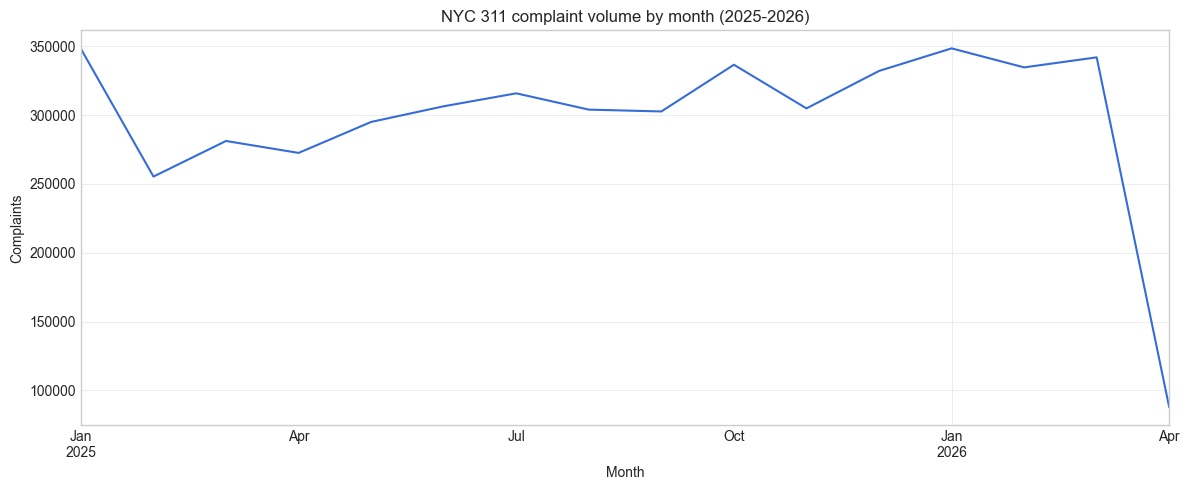

,complaints
2025 (same window),966642
2026 YTD,1112805


In [34]:
monthly_counts = df.groupby('created_month_start').size().rename('complaints')
monthly_counts.plot(figsize=(12, 5), title='NYC 311 complaint volume by month (2025-2026)')
plt.ylabel('Complaints')
plt.xlabel('Month')
plt.tight_layout()
plt.show()

latest_2026_date = df.loc[df['created_year'] == 2026, 'created_date'].max()
aligned_2025_cutoff = latest_2026_date - pd.DateOffset(years=1)
aligned_ytd = pd.Series({
    '2025 (same window)': int(df.loc[(df['created_date'] >= '2025-01-01') & (df['created_date'] <= aligned_2025_cutoff)].shape[0]),
    '2026 YTD': int(df.loc[(df['created_date'] >= '2026-01-01') & (df['created_date'] <= latest_2026_date)].shape[0]),
})
aligned_ytd.to_frame('complaints')


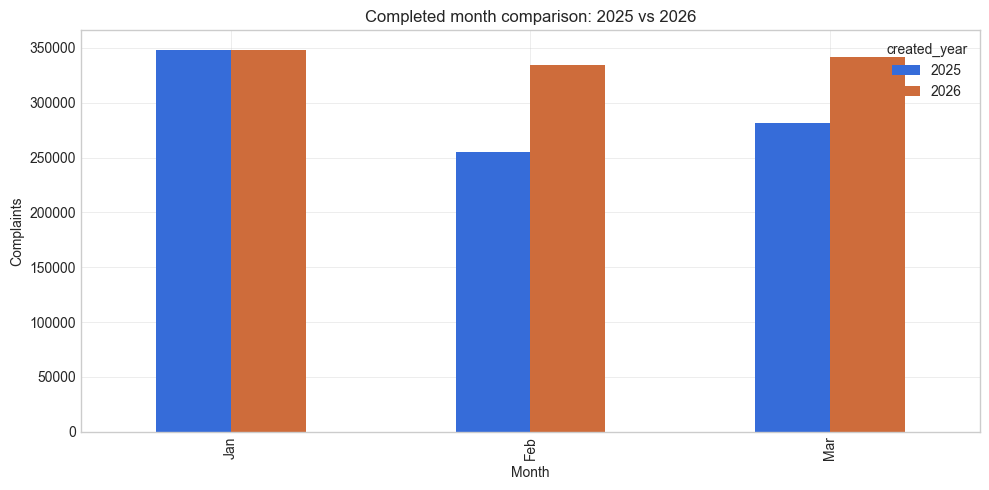

created_year,2025,2026
month_label,,
Jan,348179.0,348510.0
Feb,255364.0,334688.0
Mar,281220.0,341982.0


In [35]:
latest_month_start = latest_2026_date.to_period('M').to_timestamp()
full_month_cutoff = latest_month_start - pd.offsets.MonthBegin(1)
monthly_compare = (
    df.loc[df['created_month_start'] <= full_month_cutoff]
    .groupby(['created_year', 'created_month_start'])
    .size()
    .rename('complaints')
    .reset_index()
)
monthly_compare['month_label'] = monthly_compare['created_month_start'].dt.strftime('%b')
pivot_compare = monthly_compare.pivot(index='month_label', columns='created_year', values='complaints').reindex(['Jan', 'Feb', 'Mar'])
pivot_compare.plot(kind='bar', figsize=(10, 5), title='Completed month comparison: 2025 vs 2026')
plt.ylabel('Complaints')
plt.xlabel('Month')
plt.tight_layout()
plt.show()
pivot_compare


## Seasonal and Hourly Patterns
Phase 3 explicitly calls for seasonal and hourly patterns. These views show when complaint demand concentrates across the week, day, and season.


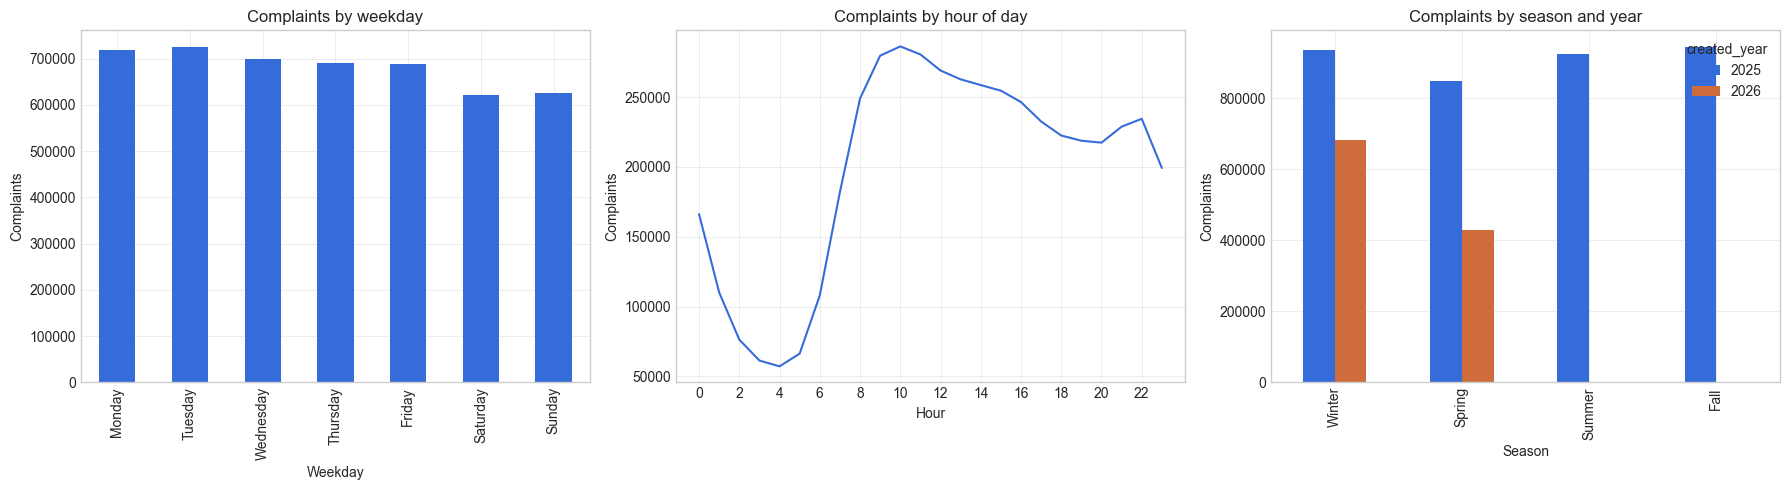

created_year,2025,2026
created_season,,
Winter,935646.0,683198.0
Spring,848827.0,429607.0
Summer,926290.0,NaN
Fall,944192.0,NaN


In [36]:
weekday_counts = df['created_weekday'].value_counts().sort_index()
hour_counts = df.groupby('created_hour').size().reindex(range(24), fill_value=0)
season_counts = (
    df.groupby(['created_year', 'created_season'], observed=True)
    .size()
    .rename('complaints')
    .reset_index()
)
season_pivot = season_counts.pivot(index='created_season', columns='created_year', values='complaints').reindex(['Winter', 'Spring', 'Summer', 'Fall'])

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
weekday_counts.plot(kind='bar', ax=axes[0], title='Complaints by weekday')
axes[0].set_xlabel('Weekday')
axes[0].set_ylabel('Complaints')

hour_counts.plot(ax=axes[1], title='Complaints by hour of day')
axes[1].set_xlabel('Hour')
axes[1].set_ylabel('Complaints')
axes[1].set_xticks(range(0, 24, 2))

season_pivot.plot(kind='bar', ax=axes[2], title='Complaints by season and year')
axes[2].set_xlabel('Season')
axes[2].set_ylabel('Complaints')

plt.tight_layout()
plt.show()

season_pivot


## Complaint Mix and Geographic Concentration
The complaint mix is heavily concentrated in a few recurring operational issues, with borough counts reflecting both population and issue-type differences.


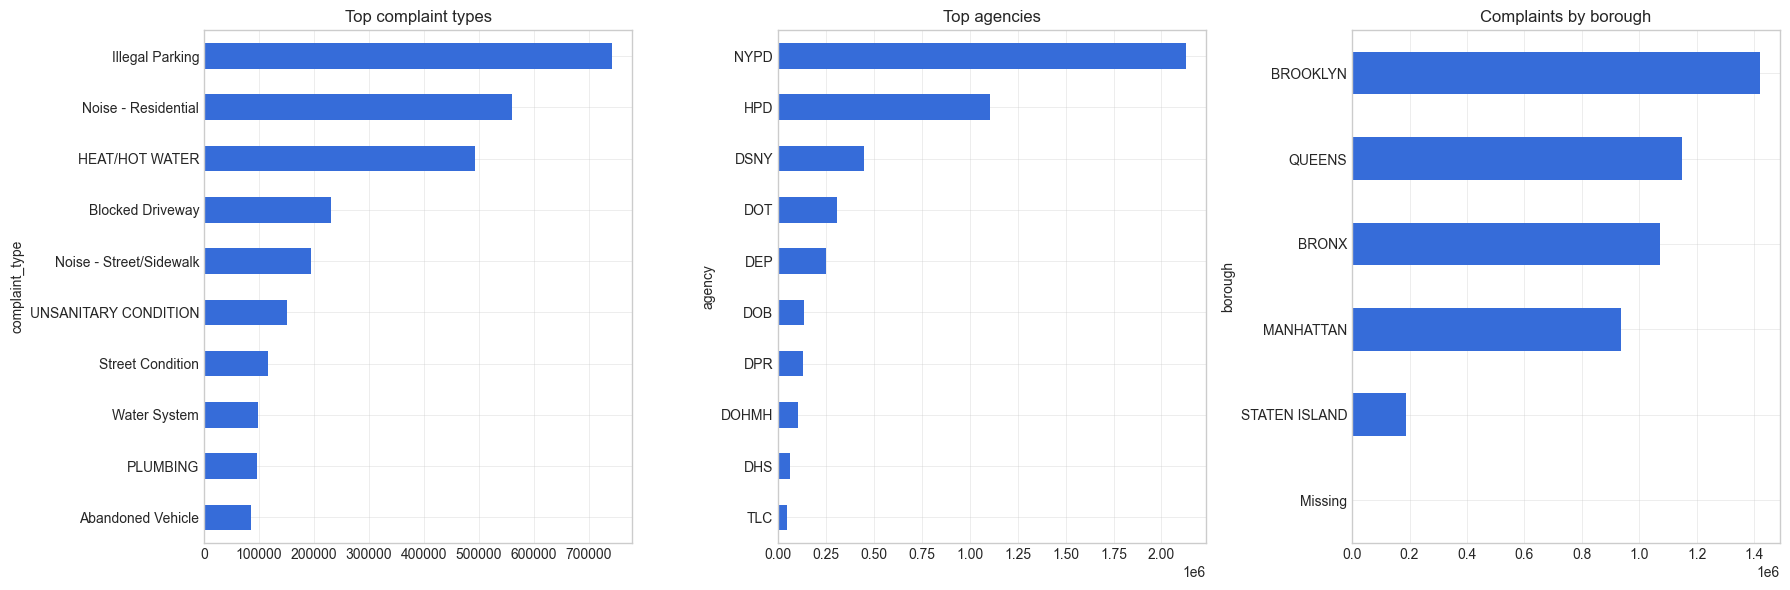

,borough,complaint_type,complaints
104,BRONX,Noise - Residential,239404
65,BRONX,HEAT/HOT WATER,173267
77,BRONX,Illegal Parking,108906
105,BRONX,Noise - Street/Sidewalk,50695
159,BRONX,UNSANITARY CONDITION,50276
255,BROOKLYN,Illegal Parking,295131
283,BROOKLYN,Noise - Residential,131512
243,BROOKLYN,HEAT/HOT WATER,130904
191,BROOKLYN,Blocked Driveway,82772
284,BROOKLYN,Noise - Street/Sidewalk,45836


In [37]:
top_complaints = df['complaint_type'].value_counts().head(10)
top_agencies = df['agency'].value_counts().head(10)
borough_counts = df['borough'].astype('string').fillna('Missing').value_counts()

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
top_complaints.sort_values().plot(kind='barh', ax=axes[0], title='Top complaint types')
top_agencies.sort_values().plot(kind='barh', ax=axes[1], title='Top agencies')
borough_counts.sort_values().plot(kind='barh', ax=axes[2], title='Complaints by borough')
plt.tight_layout()
plt.show()

top_borough_mix = (
    df.loc[df['borough'].notna()]
    .groupby(['borough', 'complaint_type'])
    .size()
    .rename('complaints')
    .reset_index()
    .sort_values(['borough', 'complaints'], ascending=[True, False])
)
top_borough_mix.groupby('borough').head(5)


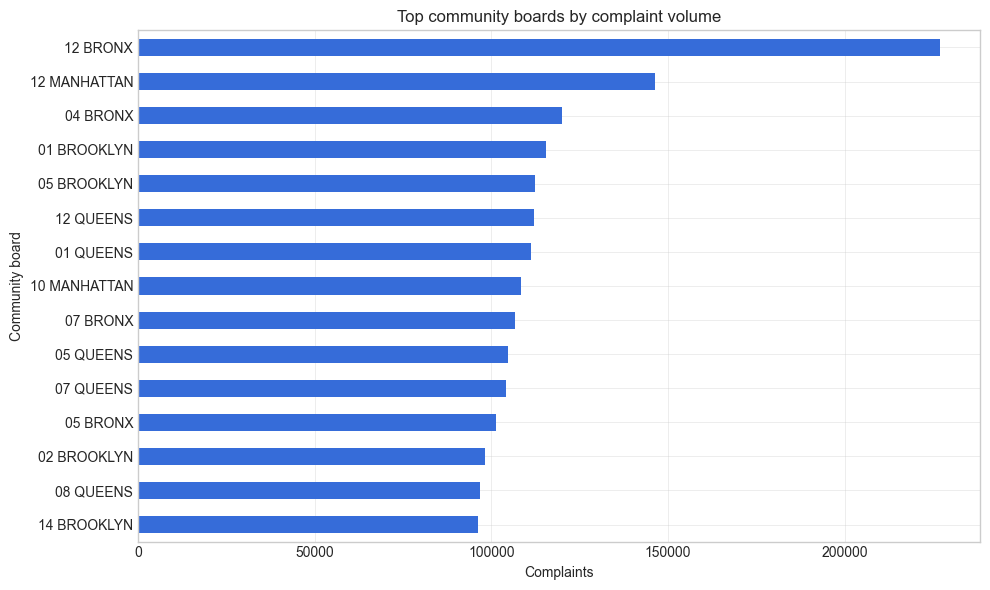

,community_board,complaint_type,complaints
69,01 BROOKLYN,Illegal Parking,23151
95,01 BROOKLYN,Noise - Residential,10406
91,01 BROOKLYN,Noise - Commercial,6619
61,01 BROOKLYN,HEAT/HOT WATER,6198
96,01 BROOKLYN,Noise - Street/Sidewalk,5601
209,04 BRONX,HEAT/HOT WATER,24987
243,04 BRONX,Noise - Residential,12414
244,04 BRONX,Noise - Street/Sidewalk,9497
285,04 BRONX,UNSANITARY CONDITION,9464
217,04 BRONX,Illegal Parking,8497


In [38]:
community_board_counts = (
    df.loc[df['community_board'].notna(), 'community_board']
    .value_counts()
    .head(15)
)

community_board_counts.sort_values().plot(kind='barh', figsize=(10, 6), title='Top community boards by complaint volume')
plt.xlabel('Complaints')
plt.ylabel('Community board')
plt.tight_layout()
plt.show()

top_community_board_mix = (
    df.loc[df['community_board'].isin(community_board_counts.head(5).index)]
    .groupby(['community_board', 'complaint_type'])
    .size()
    .rename('complaints')
    .reset_index()
    .sort_values(['community_board', 'complaints'], ascending=[True, False])
)
top_community_board_mix.groupby('community_board').head(5)


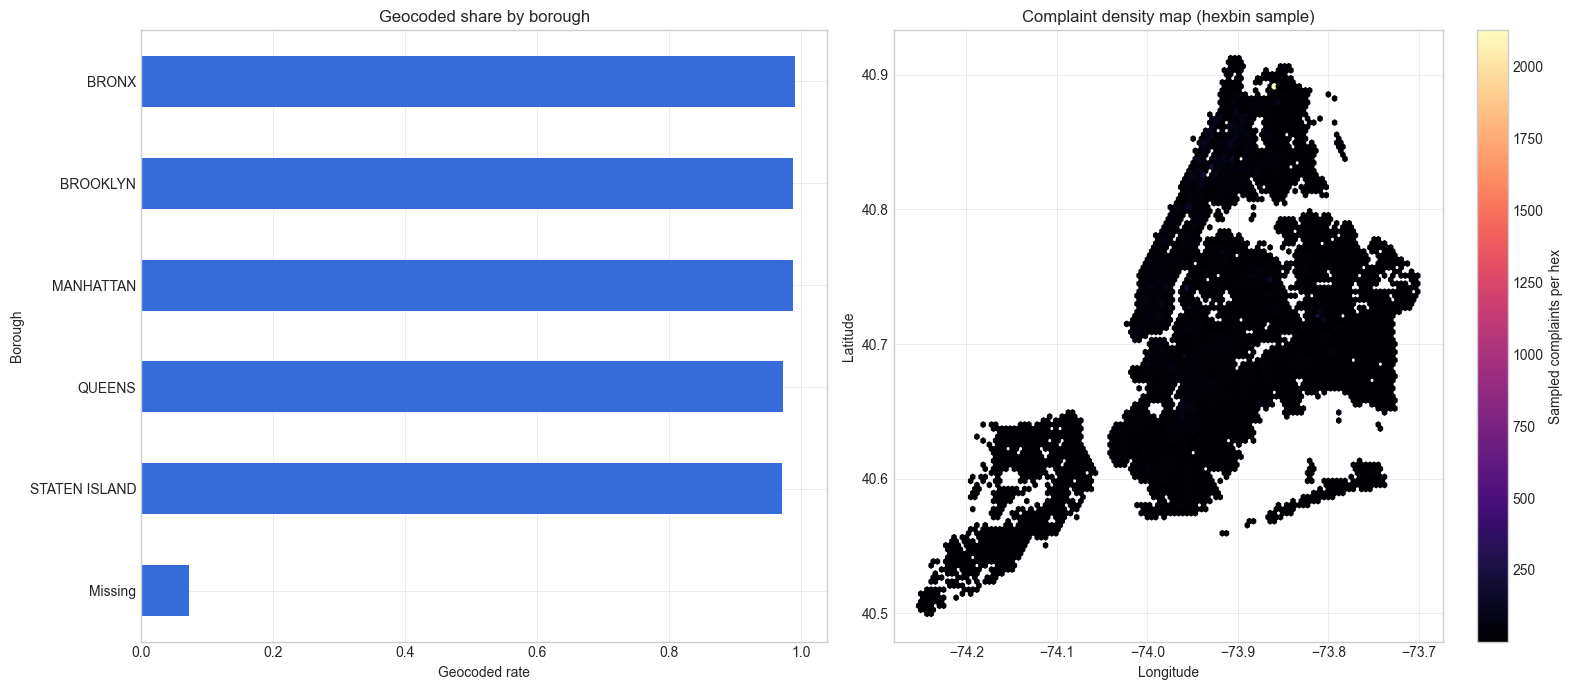

,complaints,geocoded_rate
borough,,
BROOKLYN,1418221,0.986983
QUEENS,1149340,0.972623
BRONX,1071052,0.989634
MANHATTAN,937445,0.986954
STATEN ISLAND,188122,0.970689
Missing,3580,0.073184


In [39]:
geo_quality = (
    df.assign(geocoded=~df['missing_coordinates_flag'])
    .groupby(df['borough'].astype('string').fillna('Missing'))['geocoded']
    .agg(['size', 'mean'])
    .rename(columns={'size': 'complaints', 'mean': 'geocoded_rate'})
    .sort_values('complaints', ascending=False)
)

sample_geo = df.loc[~df['missing_coordinates_flag'], ['longitude', 'latitude']].sample(min(75000, (~df['missing_coordinates_flag']).sum()), random_state=42)
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
geo_quality['geocoded_rate'].sort_values().plot(kind='barh', ax=axes[0], title='Geocoded share by borough')
axes[0].set_xlabel('Geocoded rate')
axes[0].set_ylabel('Borough')

hb = axes[1].hexbin(sample_geo['longitude'], sample_geo['latitude'], gridsize=120, cmap='magma', mincnt=1)
axes[1].set_title('Complaint density map (hexbin sample)')
axes[1].set_xlabel('Longitude')
axes[1].set_ylabel('Latitude')
fig.colorbar(hb, ax=axes[1], label='Sampled complaints per hex')

plt.tight_layout()
plt.show()

geo_quality


## Operations and Response Time Analysis
Response metrics use rows with valid non-negative `closed_date - created_date` intervals. Rows with missing or invalid close timestamps stay in the dataset, but are excluded from these calculations.


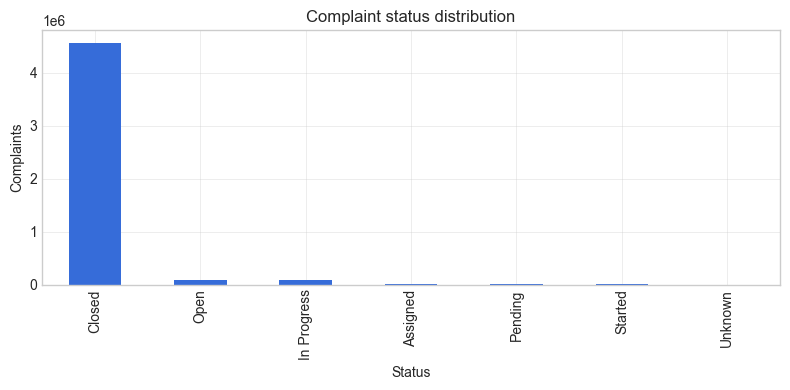

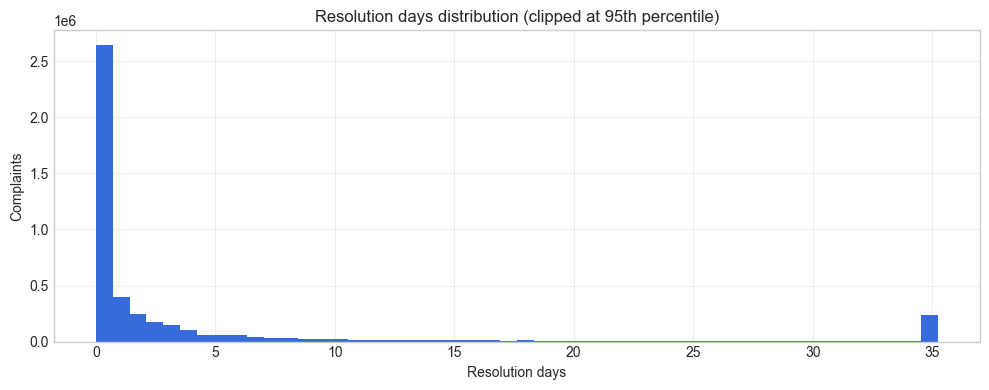

,resolution_days
count,4.584296e+06
mean,6.885998e+00
std,2.501417e+01
min,0.000000e+00
50%,2.847569e-01
90%,1.325069e+01
95%,3.524183e+01
max,4.521889e+02


In [40]:
status_counts = df['status'].value_counts()
status_counts.plot(kind='bar', figsize=(8, 4), title='Complaint status distribution')
plt.ylabel('Complaints')
plt.xlabel('Status')
plt.tight_layout()
plt.show()

valid_resolution = df.loc[df['resolved_with_valid_date'], 'resolution_days']
clip_max = valid_resolution.quantile(0.95)
plt.figure(figsize=(10, 4))
plt.hist(valid_resolution.clip(upper=clip_max), bins=50)
plt.title('Resolution days distribution (clipped at 95th percentile)')
plt.xlabel('Resolution days')
plt.ylabel('Complaints')
plt.tight_layout()
plt.show()

resolution_summary = valid_resolution.describe(percentiles=[0.5, 0.9, 0.95]).to_frame('resolution_days')
resolution_summary


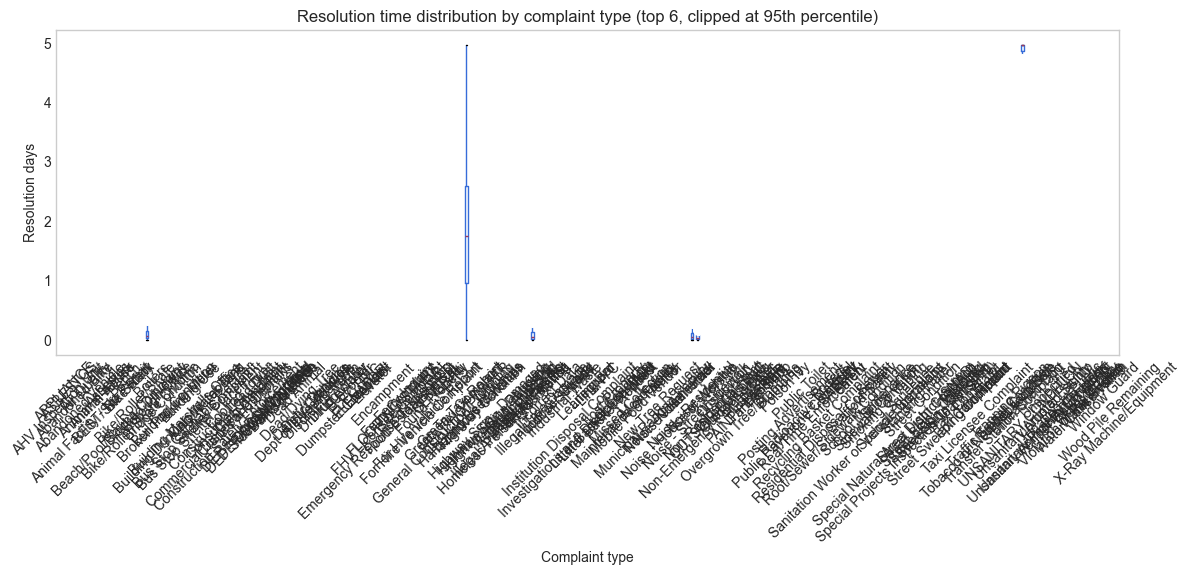

,count,mean,std,min,50%,90%,max
complaint_type,,,,,,,
Blocked Driveway,230406.0,0.137411,0.234789,0.000093,0.069977,0.305984,4.964043
HEAT/HOT WATER,479494.0,1.882008,1.183070,0.000000,1.751869,3.504850,4.964043
Illegal Parking,741552.0,0.123645,0.213637,0.000069,0.061701,0.283866,4.964043
Noise - Residential,559452.0,0.125081,0.233270,0.000035,0.050023,0.312302,4.964043
Noise - Street/Sidewalk,195213.0,0.074534,0.132056,0.000069,0.037870,0.169317,4.964043
UNSANITARY CONDITION,139790.0,4.393529,1.158094,0.000000,4.964043,4.964043,4.964043


In [41]:
top_resolved_types = (
    df.loc[df['resolved_with_valid_date'], 'complaint_type']
    .value_counts()
    .head(6)
    .index
)

resolution_boxplot = df.loc[
    df['resolved_with_valid_date'] & df['complaint_type'].isin(top_resolved_types),
    ['complaint_type', 'resolution_days']
].copy()
resolution_boxplot['resolution_days'] = resolution_boxplot['resolution_days'].clip(upper=resolution_boxplot['resolution_days'].quantile(0.95))
resolution_boxplot.boxplot(column='resolution_days', by='complaint_type', figsize=(12, 6), rot=45, grid=False)
plt.suptitle('')
plt.title('Resolution time distribution by complaint type (top 6, clipped at 95th percentile)')
plt.xlabel('Complaint type')
plt.ylabel('Resolution days')
plt.tight_layout()
plt.show()

resolution_boxplot.groupby('complaint_type')['resolution_days'].describe(percentiles=[0.5, 0.9])


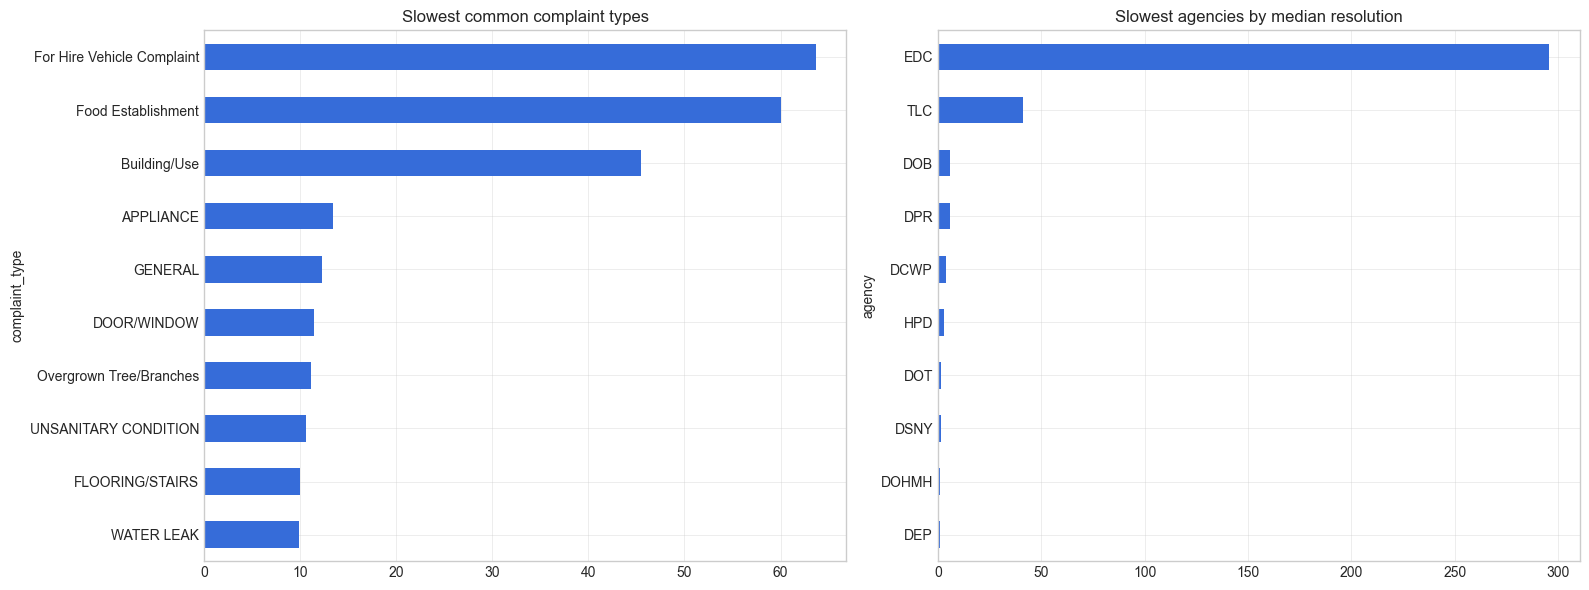

(                            volume  median_days    p90_days
 complaint_type                                             
 For Hire Vehicle Complaint   14435    63.641343  196.642752
 Food Establishment           14245    60.010417   60.267299
 Building/Use                 27475    45.439120  229.517713
 APPLIANCE                    26357    13.437072   66.028146
 GENERAL                      39549    12.283993   64.815435
 DOOR/WINDOW                  55186    11.393854   58.371962
 Overgrown Tree/Branches      13980    11.130747   95.885311
 UNSANITARY CONDITION        139790    10.568021   53.844433
 FLOORING/STAIRS              32560    10.010093   49.748623
 WATER LEAK                   48115     9.837894   56.643234,
                 volume  median_days   p90_days
 borough                                       
 STATEN ISLAND   181524     0.449832   9.995139
 MANHATTAN       887431     0.443322  19.368843
 BRONX          1039125     0.430475  13.950289
 BROOKLYN       1368950    

In [42]:
complaint_resolution = (
    df.loc[df['resolved_with_valid_date']]
    .groupby('complaint_type')['resolution_days']
    .agg(volume='size', median_days='median', p90_days=lambda s: s.quantile(0.9))
    .query('volume >= 10000')
    .sort_values('median_days', ascending=False)
)

agency_resolution = (
    df.loc[df['resolved_with_valid_date']]
    .groupby('agency')['resolution_days']
    .agg(volume='size', median_days='median', p90_days=lambda s: s.quantile(0.9))
    .query('volume >= 5000')
    .sort_values('median_days', ascending=False)
)

borough_resolution = (
    df.loc[df['resolved_with_valid_date'] & df['borough'].notna()]
    .groupby('borough')['resolution_days']
    .agg(volume='size', median_days='median', p90_days=lambda s: s.quantile(0.9))
    .sort_values('median_days', ascending=False)
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
complaint_resolution.head(10).sort_values('median_days').plot(kind='barh', y='median_days', ax=axes[0], legend=False, title='Slowest common complaint types')
agency_resolution.head(10).sort_values('median_days').plot(kind='barh', y='median_days', ax=axes[1], legend=False, title='Slowest agencies by median resolution')
plt.tight_layout()
plt.show()

complaint_resolution.head(10), borough_resolution, agency_resolution.head(10)


## Text Preview
This is a lightweight preview of the descriptor and additional-detail fields that can later support more formal NLP work.


In [43]:
top_text_complaints = df['complaint_type'].value_counts().head(5).index.tolist()
descriptor_frames = []
detail_frames = []

for complaint in top_text_complaints:
    descriptor_counts = (
        df.loc[df['complaint_type'] == complaint, 'descriptor']
        .value_counts()
        .head(8)
        .rename_axis('descriptor')
        .reset_index(name='count')
    )
    descriptor_counts.insert(0, 'complaint_type', complaint)
    descriptor_frames.append(descriptor_counts)

    detail_counts = (
        df.loc[(df['complaint_type'] == complaint) & df['additional_details'].notna(), 'additional_details']
        .value_counts()
        .head(8)
        .rename_axis('additional_details')
        .reset_index(name='count')
    )
    detail_counts.insert(0, 'complaint_type', complaint)
    detail_frames.append(detail_counts)

top_descriptors = pd.concat(descriptor_frames, ignore_index=True)
top_additional_details = pd.concat(detail_frames, ignore_index=True)
top_descriptors, top_additional_details


(             complaint_type                      descriptor   count
 0           Illegal Parking                 Blocked Hydrant  212809
 1           Illegal Parking   Posted Parking Sign Violation  170884
 2           Illegal Parking                Blocked Sidewalk  107067
 3           Illegal Parking    Commercial Overnight Parking   52606
 4           Illegal Parking               Blocked Crosswalk   42946
 5           Illegal Parking  Double Parked Blocking Traffic   40491
 6           Illegal Parking     Parking Permit Improper Use   31617
 7           Illegal Parking               Blocked Bike Lane   23092
 8       Noise - Residential                Loud Music/Party  342520
 9       Noise - Residential                Banging/Pounding  169986
 10      Noise - Residential                    Loud Talking   38829
 11      Noise - Residential                 Loud Television    8274
 12           HEAT/HOT WATER                 ENTIRE BUILDING  321458
 13           HEAT/HOT WATER      

In [44]:
top_complaint = top_complaints.index[0]
top_borough = borough_counts.index[0]
geocoded_rate = 1 - df['missing_coordinates_flag'].mean()
open_share = (~df['is_closed_status']).mean()
median_resolution = valid_resolution.median()
slowest_common_type = complaint_resolution.index[0]
ytd_change = (aligned_ytd['2026 YTD'] / aligned_ytd['2025 (same window)']) - 1

findings = [
    f'- Illegal workload remains concentrated: the top complaint type is {top_complaint} with {top_complaints.iloc[0]:,} complaints in the scoped period.',
    f'- {top_borough} has the highest complaint volume with {borough_counts.iloc[0]:,} complaints.',
    f'- {geocoded_rate:.1%} of scoped complaints have usable coordinates for spatial analysis.',
    f'- {open_share:.1%} of scoped complaints are not currently in Closed status.',
    f'- The median valid resolution time is {median_resolution:.2f} days.',
    f'- Among common complaint types, {slowest_common_type} has the slowest median resolution time.',
    f'- 2026 YTD complaint volume is {ytd_change:+.1%} versus the same 2025 window through {aligned_2025_cutoff.date()}.',
]

for finding in findings:
    print(finding)


- Illegal workload remains concentrated: the top complaint type is Illegal Parking with 741,702 complaints in the scoped period.
- BROOKLYN has the highest complaint volume with 1,418,221 complaints.
- 98.3% of scoped complaints have usable coordinates for spatial analysis.
- 4.2% of scoped complaints are not currently in Closed status.
- The median valid resolution time is 0.28 days.
- Among common complaint types, For Hire Vehicle Complaint has the slowest median resolution time.
- 2026 YTD complaint volume is +15.1% versus the same 2025 window through 2025-04-10.
